In [1]:
import sys
sys.path.insert(0, '../')

In [2]:
import warnings
warnings.filterwarnings('ignore')

import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import r2_score
from sklearn.base import clone
from tqdm import tqdm
from pickle import load

# load local variables
from src.config import *
from src.load_models import select_model
from src.utils import calculate_r2_score, calculate_per_diff, calculate_combined_r2_and_per_diff, find_adj_score, combine_all_batches, split_batches_back, perform_combat_normalization
from src.utils import calculate_y_LOD, find_score
from src.feature_selection import ModelSelection
from src.graph_visualization import feature_selection_tabularize, create_correlation_matrix, plot_model_vs_score, visualization_class_stratified
from src.outlier_detection import find_outliers_remove
from src.utils import evaluate_score_class_stratified

In [28]:
def testPerformanceWithStratified(X:pd.DataFrame,
                                    y:pd.Series,
                                    models:list,
                                    save_dir:str,
                                    weight_path:str,
                                    features_list:dict, 
                                    param_list:dict) -> None:
    
    per_diff_class_stratified_test = {'Models':[]}
    for key in sorted(y.unique()):
        per_diff_class_stratified_test[str(key)] = []
    
    y_LOD     = calculate_y_LOD(X, y)
    os.makedirs(save_dir, exist_ok=True)
    
    for metric in ['r2', 'per_diff']:
        test_score = {'Models':[], 'Scores':[]}
        for model_name in models:
            with open(f'{weight_path}/{model_name}.pkl', 'rb') as f:
                model = load(f)
                
            selected_feature_set = features_list[model_name]
            
            # Calculate the test score on the given performance metrics
            test_score['Models'].append(model_name)
        
            y_pred = model.predict(X[selected_feature_set])
            score  = find_score(y, y_pred, y_LOD=y_LOD, metric=metric, use_adjusted_r2=False, feature_len=len(selected_feature_set))
            test_score['Scores'].append(score)
    
            if (metric == 'per_diff'):
                per_diff_class_stratified_test['Models'].append(model_name)
                temp_output_per_diff = evaluate_score_class_stratified(y_pred, y, score='per_diff', y_LOD=y_LOD)
                for label in y.unique():
                    per_diff_class_stratified_test[str(label)].append(temp_output_per_diff[label]['score'])
    
        if (metric=='per_diff'):
            visualization_class_stratified(per_diff_class_stratified_test, f'{save_dir}/per_error_class_stratified.png')
        
        save_path = os.path.join(save_dir, f'test_results_{metric}.png')
        df_test_score = pd.DataFrame(test_score)
        df_test_score = df_test_score.sort_values(by='Scores')
        plot_model_vs_score(df_test_score, metric, save_path)
        plt.show()

(247, 12)


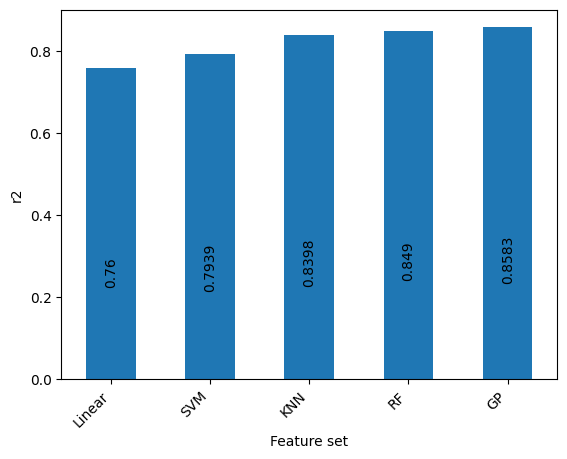

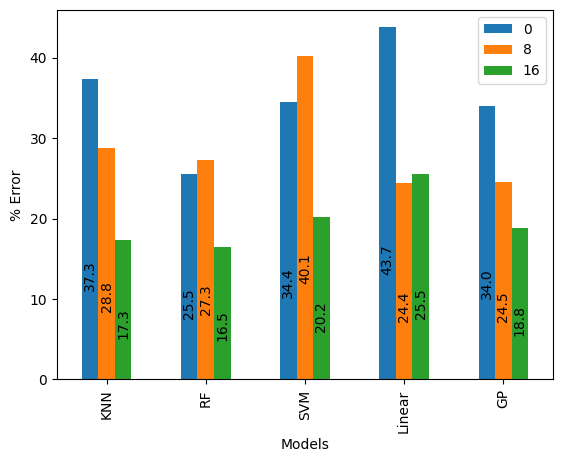

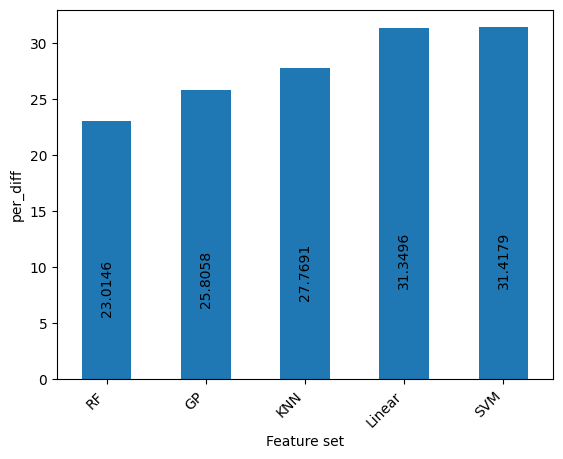

In [29]:
dataset_name = 'ML1_ML2'

if dataset_name == 'ML1_ML2':
    # Apply score to ML1/ML2 combined
    # Load Extracted features dataset

    ML1 = pd.read_excel('../dataset/2024_02_19_ML1/feature_extraction_noise_None.xlsx')
    ML2 = pd.read_excel('../dataset/2024_02_22_ML2/feature_extraction_noise_None.xlsx')
    
    final_dataset = pd.concat([ML1, ML2], ignore_index=True)

elif dataset_name == 'ML5':
    ML5_1 = pd.read_excel('../dataset/ML5/feature_extraction_noise_None.xlsx')
    final_dataset = ML5_1
    
final_dataset['label'] = final_dataset['file'].apply(lambda x: x.split('/')[-1].split('_')[-2].replace('cbz','')).apply(lambda x: int(x))
final_dataset.rename(columns={"PH": 'max(S)', 'signal_std':'std(S)', 'signal_mean':'mean(S)', 'peak area':'area(S)', \
                        'dS_dV_area':'area(dS/dV)', 'dS_dV_max_peak':'max(dS/dV)', 'dS_dV_min_peak':'min(dS/dV)',\
                    'dS_dV_peak_diff':'max(dS/dV) - min(dS/dV)', \
                    'peak V':'V_max(S)', 'dS_dV_max_V':'V_max(dS/dV)', 'dS_dV_min_V':'V_min(dS/dV)',\
        }, inplace = True)

final_dataset = final_dataset[['area(S)', 'max(S)', 'max(dS/dV)', 'min(dS/dV)', 'V_max(S)', 'vcenter', 'V_max(dS/dV)', 'V_min(dS/dV)', 'f1', 'f2', 'file', 'label']]
X = final_dataset.drop(['label', 'file'], axis=1)
y = final_dataset['label']

print(final_dataset.shape)


features_list= {'KNN':['min(dS/dV)', 'V_min(dS/dV)'], 
                'Linear':['min(dS/dV)', 'V_max(S)', 'f2'], 
                'RF':['min(dS/dV)', 'f2', 'f1', 'max(S)'], 
                'SVM':['min(dS/dV)', 'area(S)', 'V_max(S)', 'max(dS/dV)'], 
                'GP':['min(dS/dV)', 'vcenter', 'max(S)']}


param_list = {'KNN': {'n_neighbors': 3, 'weights': 'uniform', 'metric': 'euclidean'},
              'Linear': {},
              'RF': {'n_estimators': 120, 'max_depth': 10, 'min_samples_split': 6, 'min_samples_leaf': 1,  'max_features': 5},
              'SVM':{'C': 200, 'gamma': 1.0, 'kernel': 'rbf'},
              'GP': {'kernel': 1**2 * RBF(length_scale=1), 'alpha': 1.0}}

models      = ['KNN', 'RF', 'SVM', 'Linear', 'GP']
root_dir    = f'../results/Journal_paper/{dataset_name}'
weight_path = '../weights/Journal_paper'

testPerformanceWithStratified(X, y, models, root_dir, weight_path, features_list, param_list)

1.600292028515368


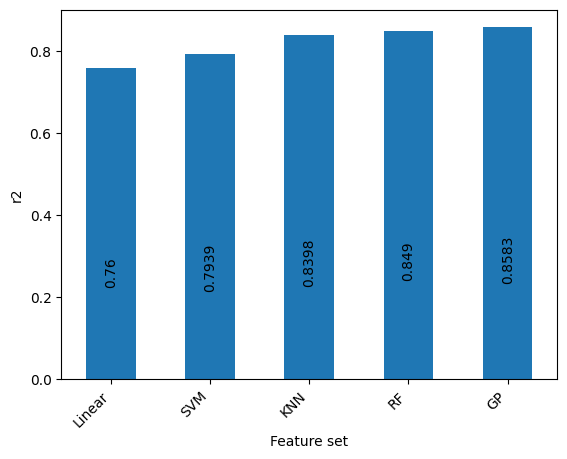

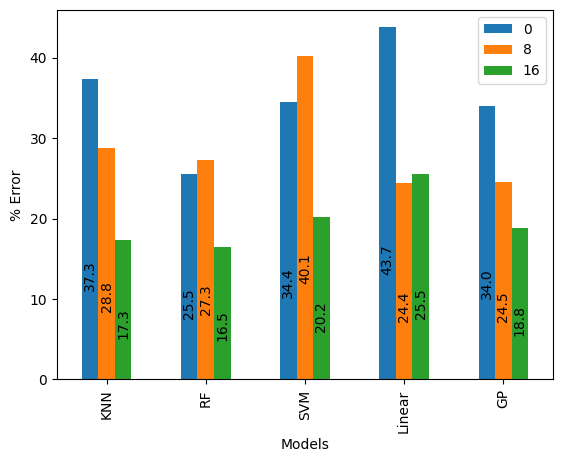

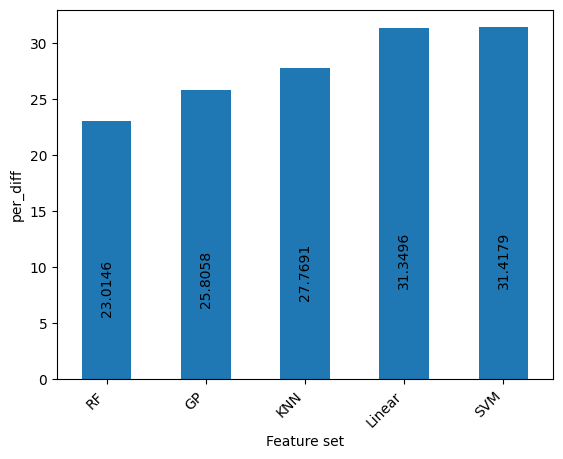

In [17]:
# features_list= {'KNN':['min(dS/dV)', 'V_min(dS/dV)'], 
#                 'Linear':['min(dS/dV)', 'V_max(S)', 'f2'], 
#                 'RF':['min(dS/dV)', 'f2', 'f1', 'max(S)'], 
#                 'SVM':['min(dS/dV)', 'area(S)', 'V_max(S)', 'max(dS/dV)'], 
#                 'GP':['min(dS/dV)', 'vcenter', 'max(S)']}


# param_list = {'KNN': {'n_neighbors': 3, 'weights': 'uniform', 'metric': 'euclidean'},
#               'Linear': {},
#               'RF': {'n_estimators': 120, 'max_depth': 10, 'min_samples_split': 6, 'min_samples_leaf': 1,  'max_features': 5},
#               'SVM':{'C': 200, 'gamma': 1.0, 'kernel': 'rbf'},
#               'GP': {'kernel': 1**2 * RBF(length_scale=1), 'alpha': 1.0}}

# add_alpha = False
# per_diff_class_stratified_test = {'Models':[], '0':[], '5':[], '8':[], '10':[], '15':[], '16':[]} if add_alpha else {'Models':[], '0':[], '8':[], '16':[]}


# models      = ['KNN', 'RF', 'SVM', 'Linear', 'GP']
# root_path   = '../results/Journal_paper'
# weight_path = '../weights/Journal_paper'
# os.makedirs(weight_path, exist_ok=True)

# y_LOD     = calculate_y_LOD(X, y)
# print(y_LOD)
# for metric in ['r2', 'per_diff']:
#     test_score = {'Models':[], 'Scores':[]}
#     for model_name in models:
#         with open(f'{weight_path}/{model_name}.pkl', 'rb') as f:
#             model = load(f)
            
#         selected_feature_set = features_list[model_name]
        
#         # Calculate the test score on the given performance metrics
#         test_score['Models'].append(model_name)
    
#         y_pred = model.predict(X[selected_feature_set])
#         score  = find_score(y, y_pred, y_LOD=y_LOD, metric=metric, use_adjusted_r2=False, feature_len=len(selected_feature_set))
#         test_score['Scores'].append(score)

#         if (metric == 'per_diff'):
#             per_diff_class_stratified_test['Models'].append(model_name)
#             temp_output_per_diff = evaluate_score_class_stratified(y_pred, y, score='per_diff', y_LOD=y_LOD)
#             for label in y.unique():
#                 per_diff_class_stratified_test[str(label)].append(temp_output_per_diff[label]['score'])

#     if (metric=='per_diff'):
#         visualization_class_stratified(per_diff_class_stratified_test, f'{root_path}/stratified_results/per_error_class_stratified.png')
    
#     save_path = os.path.join(root_path, f'Test_Results/test_results_{metric}.png')
#     os.makedirs(os.path.dirname(save_path), exist_ok=True)
#     df_test_score = pd.DataFrame(test_score)
#     df_test_score = df_test_score.sort_values(by='Scores')
#     plot_model_vs_score(df_test_score, metric, save_path)
#     plt.show()